## Optimizing performance with time constraint

In this notebook, we will use the acquisition function **EIps** to guide the search for hyperparameters. We train a simple model, to focus on how to set up this search.

With EIps or PIps guiding the hyperparameter search, the next hyperparameter combination will be selected as the combination of hyperparameters that returns the best performing model in the shortest training time.

EIps looks together at:

- maximum EI function value
- minimum training time

### Under the hood:

- the model predicts the values of the acquisition function (either EI or PI) based on their respective formula.
- predicts the time that would take to train a model based on the hyperparameters

- determines where to sample next as:

\begin{align*}
EIps = EI \times e ^{(-mu + 0.5\times std^2)}
\end{align*}

where **mu** and **std** are the time the model would take to train based on the hyperparameters.

Bigger **mu** or bigger **std**, means longer time to train, thus the np.exp() is smaller, reducing the overall value of th e EI.

Remember that big values of EI return the next hyperparameter combination to test f(x).

In [1]:
# the source code in Scikit-Optimize to calculate the EIps:

# https://github.com/scikit-optimize/scikit-optimize/blob/master/skopt/acquisition.py#L71

import numpy as np

# case 1, short training time
mu = 1
std = 1

# the EI value wihtout contemplating the time
# component
acq_vals = 2

# acq = acq / E(t)
inv_t = np.exp(-mu + 0.5*std**2)
acq_vals *= inv_t

print(inv_t)

# the EIps
print('EIps: ', acq_vals)

0.6065306597126334
EIps:  1.2130613194252668


In [2]:
# case 2, longer training time
mu = 2
std = 1

# the EI value wihtout contemplating the time
# component, same as above
acq_vals = 2

# acq = acq / E(t)
inv_t = np.exp(-mu + 0.5*std**2)
acq_vals *= inv_t

print(inv_t)

# the EIps
print('EIps: ', acq_vals)

0.22313016014842982
EIps:  0.44626032029685964


Note that when contemplating the time to run the model, when the model takes longer, the EI value decreases. So the hyperparameter combination that returns the best model in the shortest time wins. Or a combination of both rather.

Now, we implement this in Scikit-Optimize in a toy dataset from sklearn.

In [3]:
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, train_test_split

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

# for the analysis
from skopt.plots import (
    plot_convergence,
    plot_evaluations,
    plot_objective,
)

In [4]:
# load dataset

breast_cancer_X, breast_cancer_y = load_breast_cancer(return_X_y=True)
X = pd.DataFrame(breast_cancer_X)
y = pd.Series(breast_cancer_y).map({0:1, 1:0})

X.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# the target:
# percentage of benign (0) and malign tumors (1)

y.value_counts() / len(y)

0    0.627417
1    0.372583
dtype: float64

In [6]:
# split dataset into a train and test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((398, 30), (171, 30))

## Define the Hyperparameter Space

Scikit-optimize provides an utility function to create the range of values to examine for each hyperparameters. More details in [skopt.Space](https://scikit-optimize.github.io/stable/modules/generated/skopt.Space.html)

In [7]:
# determine the hyperparameter space

param_grid = [
    Integer(10, 120, name="n_estimators"),
    Real(0, 0.999, name="min_samples_split"),
    Integer(1, 5, name="max_depth"),
    Categorical(['deviance', 'exponential'], name="loss"),
]

# Scikit-optimize parameter grid is a list
type(param_grid)

list

## Define the model

In [8]:
# set up the gradient boosting classifier

gbm = GradientBoostingClassifier(random_state=0)

## Define the objective function

This is the hyperparameter response space, the function we want to minimize.

In [9]:
# We design a function to maximize the accuracy of a GBM,
# with cross-validation

# the decorator allows our objective function to receive the parameters as
# keyword arguments. This is a requirement of Scikit-Optimize.
@use_named_args(param_grid)
def objective(**params):
    
    # model with new parameters
    gbm.set_params(**params)
    
    # because we want to contemplate time in the selection
    # of the next hyperparameters, we need to capture
    # the time a model takes tot rain
    ts = datetime.datetime.now()

    # optimization function (hyperparam response function)
    # negate because we need to minimize
    value = -np.mean(
        cross_val_score(
            gbm, 
            X_train,
            y_train,
            cv=3,
            n_jobs=-4,
            scoring='accuracy')
    )

    # now we capture the time taken to train the model
    td = (datetime.datetime.now()-ts).microseconds
    
    # return performance and time
    return (value, td)

## Bayesian Optimization

We are now ready for sequential model-based optimization. Here we use Gaussian process-based Optimization.

In [10]:
# gp_minimize performs by default GP Optimization 
# using a Marten Kernel

# I want to know how long this search takes
t_now = datetime.datetime.now()

gp_ = gp_minimize(
    objective, # the objective function to minimize
    param_grid, # the hyperparameter space
    n_initial_points=10, # the number of points to evaluate f(x) to start of
    acq_func='EIps', # the acquisition function
    n_calls=30, # the number of subsequent evaluations of f(x)
    random_state=0, 
)


t_end = (datetime.datetime.now()-t_now).seconds

print(f"search took {t_end} seconds")

search took 25 seconds


In [11]:
# function value at the minimum.
# note that it is the negative of the accuracy

"Best score=%.4f" % gp_.fun

'Best score=-0.9673'

In [12]:
print("""Best parameters:
=========================
- n_estimators=%d
- min_samples_split=%.6f
- max_depth=%d
- loss = %s""" % (gp_.x[0], 
                gp_.x[1],
                gp_.x[2],
                gp_.x[3]))

Best parameters:
- n_estimators=119
- min_samples_split=0.993699
- max_depth=5
- loss = exponential


## Evaluate convergence of the search

[plot_convergence](https://scikit-optimize.github.io/stable/modules/generated/skopt.plots.plot_convergence.html#skopt.plots.plot_convergence)

<AxesSubplot:title={'center':'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

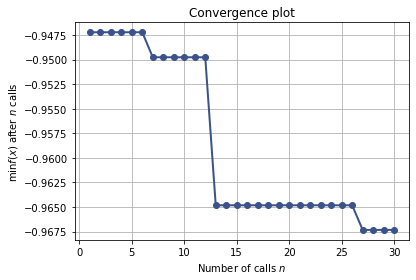

In [13]:
plot_convergence(gp_)

## Partially dependency plots

[plot_objective](https://scikit-optimize.github.io/stable/modules/generated/skopt.plots.plot_objective.html#skopt.plots.plot_objective)

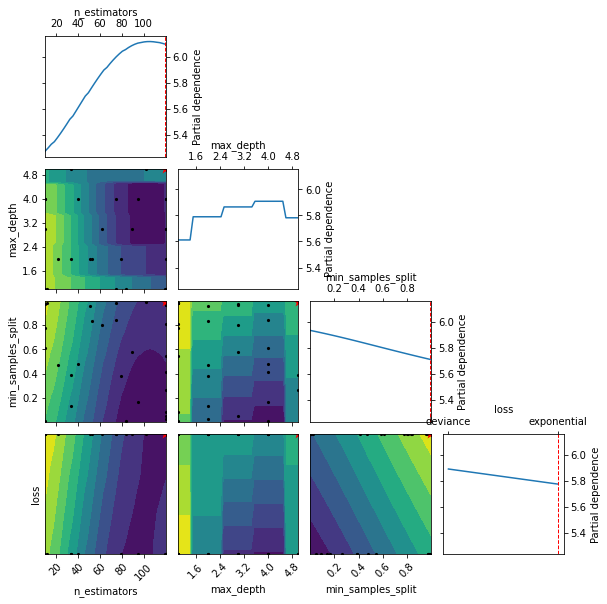

In [14]:
dim_names = ['n_estimators', 'max_depth', 'min_samples_split', 'loss']
plot_objective(result=gp_, plot_dims=dim_names)
plt.show()

## Evaluate hyperparameter exploration

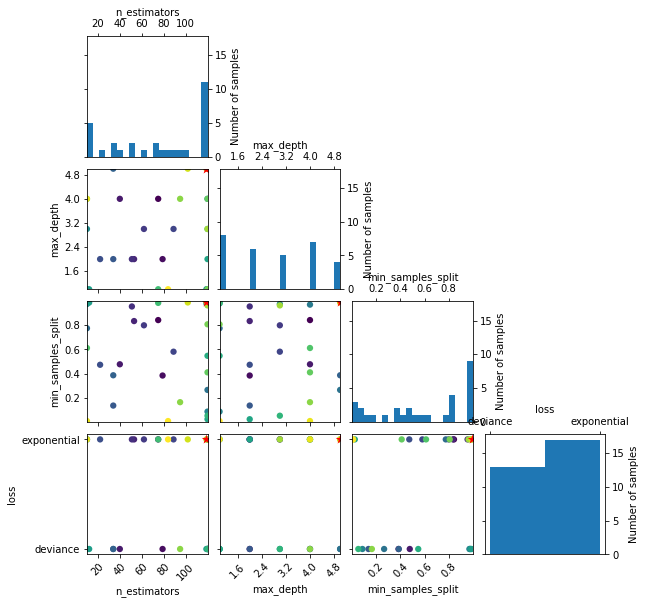

In [15]:
dim_names = ['n_estimators', 'max_depth', 'min_samples_split', 'loss']
plot_evaluations(result=gp_, plot_dims=dim_names)
plt.show()

In [16]:
# the search results contain the hyperparamters tested
# the accuracy as well as the training time

tmp = pd.concat([
    pd.DataFrame(gp_.x_iters),
    pd.Series(gp_.func_vals),
    pd.Series(gp_.log_time)
], axis=1)

tmp.columns = dim_names + ['accuracy'] + ['time']

tmp.head()

,n_estimators,max_depth,min_samples_split,loss,accuracy,time
0,75,0.843421,4,exponential,-0.947217,12.743276
1,79,0.383997,2,deviance,-0.942223,13.061192
2,40,0.477187,4,deviance,-0.942242,12.602134
3,53,0.835243,2,exponential,-0.944710,12.255563
4,51,0.956198,2,exponential,-0.944710,12.117957


Text(0.5, 1.0, 'GBMs with more estimators take longer to train')

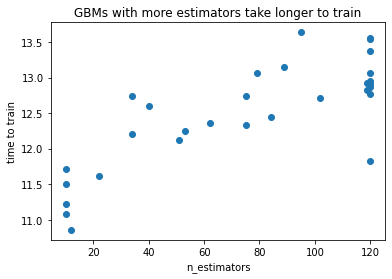

In [17]:
plt.scatter(tmp['n_estimators'], tmp['time'])
plt.ylabel('time to train')
plt.xlabel('n_estimators')
plt.title('GBMs with more estimators take longer to train')

Text(0.5, 1.0, 'min_samples_split does not affect much the training time')

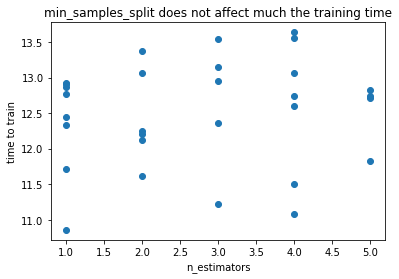

In [18]:
plt.scatter(tmp['min_samples_split'], tmp['time'])
plt.ylabel('time to train')
plt.xlabel('n_estimators')
plt.title('min_samples_split does not affect much the training time')

Text(0.5, 1.0, 'More complex models return better accuracy\n they take longer to train')

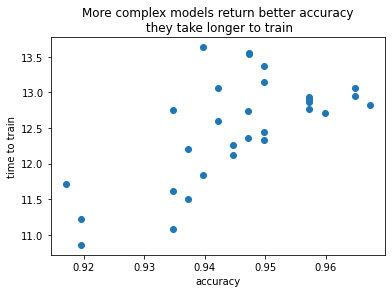

In [19]:
plt.scatter(-tmp['accuracy'], tmp['time'])
plt.ylabel('time to train')
plt.xlabel('accuracy')
plt.title('More complex models return better accuracy\n they take longer to train')

## Compare to naive Bayesian Search

Now I will perform a normal Bayesian Search for hyperparameters, where I do not consider the time in the search for hyperparameters.

In [20]:
@use_named_args(param_grid)
def objective(**params):
    
    # model with new parameters
    gbm.set_params(**params)

    # optimization function (hyperparam response function)
    # negate because we need to minimize
    value = -np.mean(
        cross_val_score(
            gbm, 
            X_train,
            y_train,
            cv=3,
            n_jobs=-4,
            scoring='accuracy')
    )
    
    return value

In [21]:
# gp_minimize performs by default GP Optimization 
# using a Marten Kernel

t_now = datetime.datetime.now()

gp_ = gp_minimize(
    objective, # the objective function to minimize
    param_grid, # the hyperparameter space
    n_initial_points=10, # the number of points to evaluate f(x) to start of
    acq_func='EI', # the acquisition function
    n_calls=20, # the number of subsequent evaluations of f(x)
    random_state=0, 
)

t_end = (datetime.datetime.now()-t_now).seconds

print(f"search took {t_end} seconds")

search took 12 seconds


Surprisingly the search took shorter.

In [22]:
# function value at the minimum.
# note that it is the negative of the accuracy

"Best score=%.4f" % gp_.fun

'Best score=-0.9724'

In [23]:
print("""Best parameters:
=========================
- n_estimators=%d
- min_samples_split=%.6f
- max_depth=%d
- loss = %s""" % (gp_.x[0], 
                gp_.x[1],
                gp_.x[2],
                gp_.x[3]))

Best parameters:
- n_estimators=120
- min_samples_split=0.681272
- max_depth=5
- loss = deviance


<AxesSubplot:title={'center':'Convergence plot'}, xlabel='Number of calls $n$', ylabel='$\\min f(x)$ after $n$ calls'>

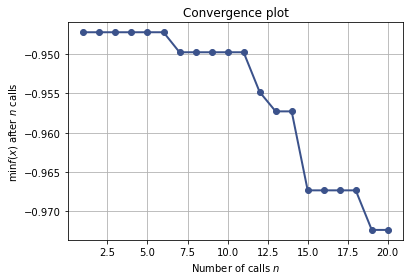

In [24]:
plot_convergence(gp_)

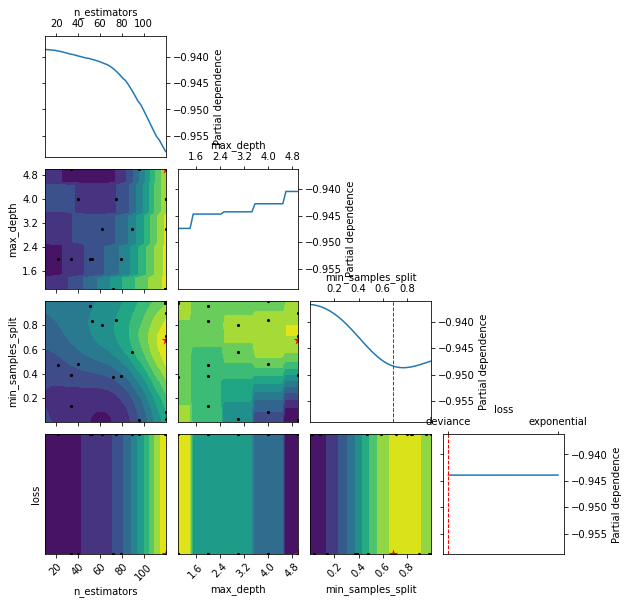

In [25]:
## Partially dependency 

plot_objective(result=gp_, plot_dims=dim_names)
plt.show()

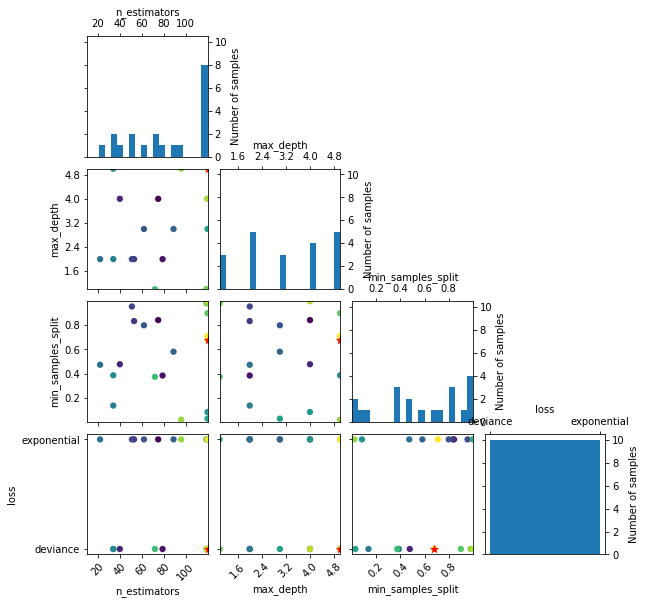

In [26]:
plot_evaluations(result=gp_, plot_dims=dim_names)
plt.show()